<a href="https://colab.research.google.com/github/NguyenHuy2003/DATN/blob/main/Train_Model_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
import numpy as np
import os
import glob

# 1. Thiết lập chạy đa GPU

strategy = tf.distribute.MirroredStrategy()
print(f"Số lượng GPU đang sử dụng: {strategy.num_replicas_in_sync}")

# Từ động tìm đường dẫn dữ liệu
TRAIN_DIR = ""
VAL_DIR = ""

print("Đang tìm kiếm đường dẫn:")
for root, dirs, files in os.walk('/kaggle/input'):
    if '/train/' in root.replace('\\', '/') and any(f.endswith('.png') for f in files):
        TRAIN_DIR = root.replace('\\', '/').split('/train/')[0] + '/train/'
    if '/valid/' in root.replace('\\', '/') and any(f.endswith('.png') for f in files):
        VAL_DIR = root.replace('\\', '/').split('/valid/')[0] + '/valid/'

    if TRAIN_DIR and VAL_DIR:
        break # Tìm thấy cả 2 thì dừng tìm kiếm cho nhanh

print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"VAL_DIR: {VAL_DIR}")
# ----------------------------------------------

# Lưu checkpoint /kaggle/working/
CHECKPOINT_DIR = '/kaggle/working/'

IMG_SIZE = 320
GLOBAL_BATCH_SIZE = 32 * strategy.num_replicas_in_sync
AUTOTUNE = tf.data.AUTOTUNE

PARTS_MAP = {
    'XR_ELBOW': 0, 'XR_FINGER': 1, 'XR_FOREARM': 2,
    'XR_HAND': 3, 'XR_HUMERUS': 4, 'XR_SHOULDER': 5, 'XR_WRIST': 6
}

# 2. Data pipeline
def load_multitask_data(data_dir):
    print(f"Đọc thư mục: {data_dir}")
    image_paths = glob.glob(os.path.join(data_dir, "**", "*.png"), recursive=True)
    abnormal_labels, part_labels = [], []

    for path in image_paths:
        norm_path = path.replace('\\', '/')
        abnormal_labels.append(1 if 'positive' in norm_path else 0)

        part_found = False
        for part_name, part_idx in PARTS_MAP.items():
            if part_name in norm_path:
                part_labels.append(part_idx)
                part_found = True
                break
        if not part_found: part_labels.append(-1)

    print(f"   -> Đã load {len(image_paths)} ảnh.")
    return image_paths, abnormal_labels, part_labels

def process_path_mtl(file_path, ab_label, part_label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])

    labels_dict = {'abnormality_out': ab_label, 'part_out': part_label}
    return img, labels_dict

def create_mtl_dataset(paths, ab_labels, part_labels, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, ab_labels, part_labels))
    ds = ds.map(process_path_mtl, num_parallel_calls=AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=10000)
    return ds.batch(GLOBAL_BATCH_SIZE).prefetch(AUTOTUNE)

train_paths, train_ab_labels, train_part_labels = load_multitask_data(TRAIN_DIR)
val_paths, val_ab_labels, val_part_labels = load_multitask_data(VAL_DIR)

train_ds = create_mtl_dataset(train_paths, train_ab_labels, train_part_labels, is_training=True)
val_ds = create_mtl_dataset(val_paths, val_ab_labels, val_part_labels, is_training=False)


# 3. Xây dựng mô hình bên trong STRATEGY SCOPE
def build_mtl_model(input_shape=(320, 320, 1)):
    inputs = layers.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.05)(x)

    x = layers.Conv2D(3, (3, 3), padding='same', use_bias=False)(x)

    backbone = applications.DenseNet169(include_top=False, weights='imagenet', input_shape=(320, 320, 3))
    backbone.trainable = False
    shared_features = backbone(x, training=False)

    # Nhánh 1: Dự đoán bệnh (Main Task)
    avg_pool_1 = layers.GlobalAveragePooling2D()(shared_features)
    max_pool_1 = layers.GlobalMaxPooling2D()(shared_features)
    x1 = layers.Concatenate()([avg_pool_1, max_pool_1])

    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.3)(x1)
    x1 = layers.Dense(512, activation='relu')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.3)(x1)
    out_abnormality = layers.Dense(1, activation='sigmoid', name='abnormality_out')(x1)

    # Nhánh 2: Phân loại xương (Auxiliary Task)
    x2 = layers.GlobalAveragePooling2D()(shared_features)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dropout(0.2)(x2)
    out_part = layers.Dense(7, activation='softmax', name='part_out')(x2)

    return models.Model(inputs=inputs, outputs=[out_abnormality, out_part], name="MURA_MTL_DualGPU")

# Mọi thứ liên quan đến tạo model, hàm loss, và compile nằm trong SCOPE
with strategy.scope():
    model = build_mtl_model()

    # Khởi tạo Focal Loss
    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

    LOSSES = {
        'abnormality_out': focal_loss,
        'part_out': 'sparse_categorical_crossentropy'
    }

    LOSS_WEIGHTS = {'abnormality_out': 1.0, 'part_out': 0.2}

    METRICS = {
        'abnormality_out': [tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')],
        'part_out': ['accuracy']
    }

    # [QUAN TRỌNG]: Thêm clipnorm=1.0 để khống chế đạo hàm, chống sập mô hình.
    optimizer_stage1 = optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

    # Compile Giai đoạn 1
    model.compile(optimizer=optimizer_stage1, loss=LOSSES, loss_weights=LOSS_WEIGHTS, metrics=METRICS)

model.summary()

# 4. Callback và huấn luyện
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_mura_multitask.keras')

my_callbacks = [
    callbacks.ModelCheckpoint(checkpoint_path, monitor='val_abnormality_out_auc', verbose=1, save_best_only=True, mode='max'),
    callbacks.EarlyStopping(monitor='val_abnormality_out_auc', patience=6, restore_best_weights=True, mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_abnormality_out_auc', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(os.path.join(CHECKPOINT_DIR, 'training_log.csv'), append=True)
]

print("\nGiai đoạn 1: Transfer Learning")
history_1 = model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=my_callbacks)

print("\nGiai đoạn 2: Fine-Tuning Toàn bộ mạng")
# Chuyển đổi trạng thái trainable phải thực hiện lại compile bên trong scope
with strategy.scope():
    model.trainable = True

    # [QUAN TRỌNG]: Thêm clipnorm=1.0 cho Giai đoạn 2
    optimizer_stage2 = optimizers.Adam(learning_rate=1e-5, clipnorm=1.0)
    model.compile(optimizer=optimizer_stage2, loss=LOSSES, loss_weights=LOSS_WEIGHTS, metrics=METRICS)

history_fine = model.fit(
    train_ds, validation_data=val_ds, epochs=20,
    initial_epoch=history_1.epoch[-1],
    callbacks=my_callbacks
)

print(f"\nHoàn thành! Model đã được lưu tại: {checkpoint_path}")

2026-03-04 19:18:02.646970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772651883.162372     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772651883.263193     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772651884.259724     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772651884.259766     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772651884.259769     120 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1772651921.103924     120 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772651921.110353     120 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Số lượng GPU đang sử dụng: 2
Đang tìm kiếm đường dẫn:
TRAIN_DIR: /kaggle/input/datasets/huyzakaito/mura-clahe-320/data_clahe_320/train/
VAL_DIR: /kaggle/input/datasets/huyzakaito/mura-clahe-320/data_clahe_320/valid/
Đọc thư mục: /kaggle/input/datasets/huyzakaito/mura-clahe-320/data_clahe_320/train/
   -> Đã load 36811 ảnh.
Đọc thư mục: /kaggle/input/datasets/huyzakaito/mura-clahe-320/data_clahe_320/valid/
   -> Đã load 3197 ảnh.
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MURA_MTL_DualGPU"

...

 Trainable params: 2,140,707 (8.17 MB)

 Non-trainable params: 12,650,560 (48.26 MB)


Giai đoạn 1: Transfer Learning
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/devic

I0000 00:00:1772652219.437371     183 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772652219.437401     185 cuda_dnn.cc:529] Loaded cuDNN version 91002


576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - abnormality_out_auc: 0.6812 - abnormality_out_loss: 0.3551 - abnormality_out_recall: 0.5695 - loss: 0.4059 - part_out_accuracy: 0.9200 - part_out_loss: 0.2540
Epoch 1: val_abnormality_out_auc improved from -inf to 0.78410, saving model to /kaggle/working/best_mura_multitask.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 510s 800ms/step - abnormality_out_auc: 0.6812 - abnormality_out_loss: 0.3549 - abnormality_out_recall: 0.5695 - loss: 0.4057 - part_out_accuracy: 0.9200 - part_out_loss: 0.2541 - val_abnormality_out_auc: 0.7841 - val_abnormality_out_loss: 0.1460 - val_abnormality_out_recall: 0.4954 - val_loss: 0.2044 - val_part_out_accuracy: 0.9093 - val_part_out_loss: 0.2917 - learning_rate: 0.0010
Epoch 2/12
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - abnormality_out_auc: 0.7677 - abnormality_out_loss: 0.1435 - abnormality_out_recall: 0.5838 - loss: 0.1620 - part_out_accuracy: 0.9679 - part_out_loss: 0.0927
Epoch 2: val_abnormality_out_auc improved fr

In [1]:
# Liên kết drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


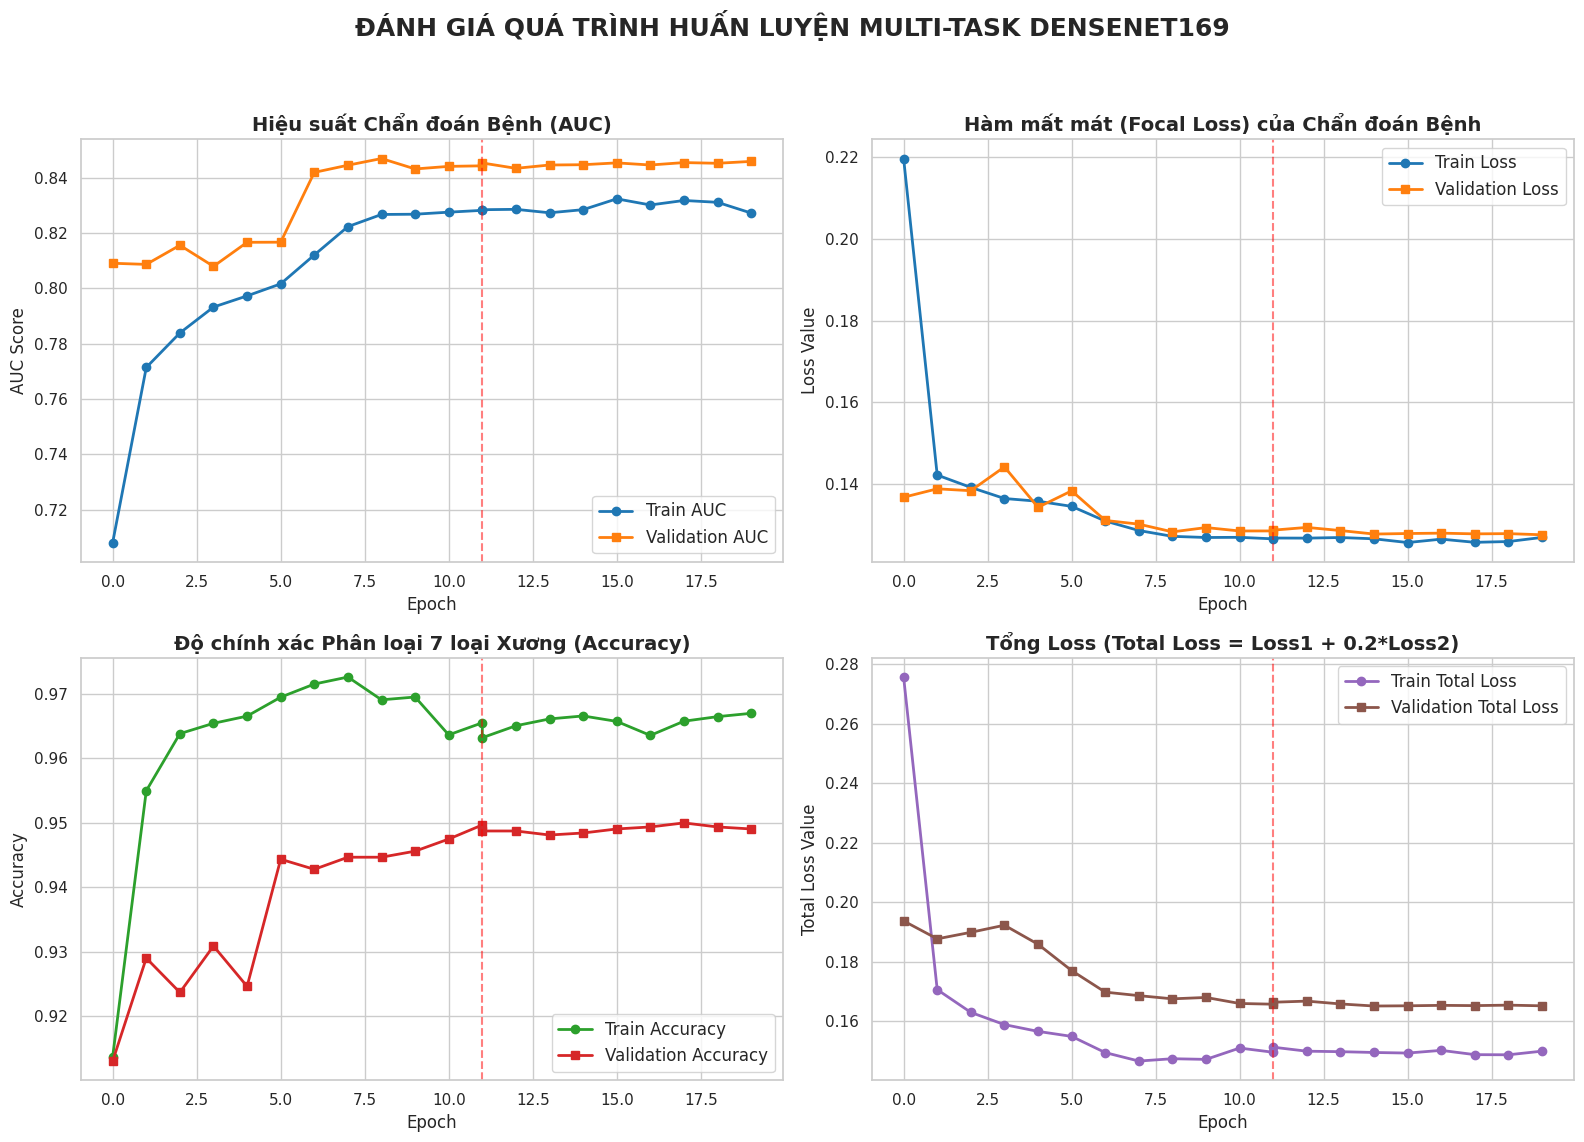

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Thiết lập phong cách đồ thị (chuẩn báo cáo khoa học)
sns.set_theme(style="whitegrid")

# 2. Đọc dữ liệu từ file csv vừa kéo về
csv_path = '/content/drive/MyDrive/DATN-NguyenVanHuy-2121050061/model_full/training_log.csv'

if not os.path.exists(csv_path):
    print(f"Không tìm thấy file tại {csv_path}. Bạn hãy kiểm tra lại tên file nhé!")
else:
    df = pd.read_csv(csv_path)

    # 3. Tạo khung vẽ gồm 4 biểu đồ (2 hàng x 2 cột)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ĐÁNH GIÁ QUÁ TRÌNH HUẤN LUYỆN MULTI-TASK DENSENET169', fontsize=18, fontweight='bold')

    # --- Biểu đồ 1: Chỉ số AUC (Nhánh chẩn đoán bệnh) ---
    axes[0, 0].plot(df['epoch'], df['abnormality_out_auc'], label='Train AUC', color='#1f77b4', linewidth=2, marker='o')
    axes[0, 0].plot(df['epoch'], df['val_abnormality_out_auc'], label='Validation AUC', color='#ff7f0e', linewidth=2, marker='s')
    axes[0, 0].set_title('Hiệu suất Chẩn đoán Bệnh (AUC)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('AUC Score', fontsize=12)
    axes[0, 0].legend(loc='lower right', fontsize=12)
    axes[0, 0].axvline(x=11, color='red', linestyle='--', alpha=0.5, label='Bắt đầu Fine-tuning')

    # --- Biểu đồ 2: Hàm Loss (Nhánh chẩn đoán bệnh) ---
    axes[0, 1].plot(df['epoch'], df['abnormality_out_loss'], label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
    axes[0, 1].plot(df['epoch'], df['val_abnormality_out_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')
    axes[0, 1].set_title('Hàm mất mát (Focal Loss) của Chẩn đoán Bệnh', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss Value', fontsize=12)
    axes[0, 1].legend(loc='upper right', fontsize=12)
    axes[0, 1].axvline(x=11, color='red', linestyle='--', alpha=0.5)

    # --- Biểu đồ 3: Độ chính xác (Nhánh Phân loại Xương) ---
    axes[1, 0].plot(df['epoch'], df['part_out_accuracy'], label='Train Accuracy', color='#2ca02c', linewidth=2, marker='o')
    axes[1, 0].plot(df['epoch'], df['val_part_out_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2, marker='s')
    axes[1, 0].set_title('Độ chính xác Phân loại 7 loại Xương (Accuracy)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].legend(loc='lower right', fontsize=12)
    axes[1, 0].axvline(x=11, color='red', linestyle='--', alpha=0.5)

    # --- Biểu đồ 4: Tổng Loss của toàn mạng (Total Loss) ---
    axes[1, 1].plot(df['epoch'], df['loss'], label='Train Total Loss', color='#9467bd', linewidth=2, marker='o')
    axes[1, 1].plot(df['epoch'], df['val_loss'], label='Validation Total Loss', color='#8c564b', linewidth=2, marker='s')
    axes[1, 1].set_title('Tổng Loss (Total Loss = Loss1 + 0.2*Loss2)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Total Loss Value', fontsize=12)
    axes[1, 1].legend(loc='upper right', fontsize=12)
    axes[1, 1].axvline(x=11, color='red', linestyle='--', alpha=0.5)

    # 4. Tinh chỉnh khoảng cách và xuất hình ảnh
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])


    # Hiển thị biểu đồ ngay trên Colab
    plt.show()

1. Nhánh Phân loại Xương (Auxiliary Task): THÀNH CÔNG RỰC RỠNgay từ Epoch đầu tiên, mô hình đã nhận diện 7 loại xương cực kỳ tốt.Độ chính xác trên tập Validation (val_part_out_accuracy): Bắt đầu ở mức 90.9% và nhanh chóng tăng lên ~94.8% ở cuối Giai đoạnn 2.
Nhận xét: Việc nhận diện các loại xương khác nhau (cổ tay, khuỷu tay, ngón tay...) qua ảnh X-quang giờ đây đã trở nên quá dễ dàng với DenseNet169. Hàm Loss của nhánh này (part_out_loss) giảm rất ổn định, chứng tỏ phần xương sống (backbone) đã trích xuất được những đặc trưng hình học xuất sắc.

2. Nhánh Dự đoán Bệnh (Main Task): ĐẠT CHUẨN MURAĐây mới là thử thách chính, và mô hình của bạn đã không làm chúng ta thất vọng.Chỉ số AUC (val_abnormality_out_auc):Bắt đầu ở Epoch 1: 0.7841 (Rất khá)Đỉnh điểm (Epoch 18): 0.8412Chỉ số Recall (val_abnormality_out_recall): Tăng từ 49% lên đến ~57.9%.Nhận xét: Mức AUC > 0.84 trên bộ dữ liệu MURA là một kết quả rất đáng gờm (tiệm cận với mức hiệu suất của các bác sĩ X-quang). Việc Recall tăng dần chứng tỏ Focal Loss đang làm đúng nhiệm vụ của nó: ép mô hình phải chú ý nhiều hơn vào các ca bệnh khó (abnormal), giảm tỷ lệ bỏ sót bệnh nhân.

3. Đánh giá chiến lược Huấn luyện (Training Strategy)Nhìn vào log, chúng ta có thể thấy các cơ chế tự động đã hoạt động hoàn hảo:Transfer Learning (Giai đoạn 1): Rất hiệu quả. Việc đóng băng mạng gốc giúp mô hình nhanh chóng hội tụ mà không phá vỡ trọng số của ImageNet.Fine-Tuning (Giai đoạn 2): Việc mở khóa toàn bộ mạng và dùng Learning Rate cực nhỏ ($1e^{-5}$) đã giúp mô hình "bào" thêm được một chút hiệu suất (AUC nhích từ 0.8409 lên 0.8412).Learning Rate Scheduler: Bạn có thể thấy các dòng ReduceLROnPlateau reducing learning rate.... Cơ chế này đã can thiệp rất đúng lúc khi thấy mô hình có dấu hiệu chững lại, giúp Loss tiếp tục giảm sâu hơn thay vì bị dao động.